# 14 - Training CNN Transfer Learning (ResNet18 - 4 Class)

**Tujuan:** Melatih model CNN Transfer Learning (ResNet18 pretrained di ImageNet) untuk pengenalan emosi menggunakan fitur penampilan dari citra wajah 224x224 dengan 4 kelas emosi.

**Mapping:** neutral, happy, sad, negative (angry+fearful+disgusted+surprised)

**Arsitektur:** ResNet18 pretrained -> 512-dim -> Dense(256) -> Dense(128) -> 4 classes

**3 Skenario Imbalance:**
- B1: Tanpa penanganan (baseline)
- B2: Dengan class weights (Cui et al., 2019)
- B3: Dengan class weights + augmentasi

## 1. Setup

In [1]:
import sys
import os
import json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionCNNTransfer
from training.utils import (
    EmotionImageDataset, get_class_weights,
    train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
# Config
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_4class"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_4class_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "4class" / "cnn_transfer"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.00005
PATIENCE = 15
NUM_CLASSES = 4

EMOTIONS = ["neutral", "happy", "sad", "negative"]
print(f"Dataset: {DATASET_DIR}")
print(f"Dataset augmented: {DATASET_AUG_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_4class
Dataset augmented: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_4class_augmented
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/cnn_transfer


## 2. Load Data

In [3]:
from torch.utils.data import DataLoader
from collections import Counter

def load_dataloaders(dataset_dir, batch_size=32):
    """Load train/val/test dataloaders."""
    train_ds = EmotionImageDataset(
        dataset_dir / "X_train_images.npy",
        dataset_dir / "y_train.npy"
    )
    val_ds = EmotionImageDataset(
        dataset_dir / "X_val_images.npy",
        dataset_dir / "y_val.npy"
    )
    test_ds = EmotionImageDataset(
        dataset_dir / "X_test_images.npy",
        dataset_dir / "y_test.npy"
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Print info
    y_train = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y_train.tolist())
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"Train distribution:")
    for i, emo in enumerate(EMOTIONS):
        print(f"  {emo:>10s}: {counts.get(i, 0)}")

    return train_loader, val_loader, test_loader

# Load original dataset
train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 7064 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
    negative: 145


## 3. Skenario B1: Baseline (Tanpa Class Weights)

In [4]:
# B1: Baseline - no class weights
model_b1 = EmotionCNNTransfer(num_classes=4, pretrained=True).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print(f"Model parameters: {sum(p.numel() for p in model_b1.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model_b1.parameters() if p.requires_grad):,}")
print("Training B1 (baseline)...")
history_b1, best_epoch_b1 = train_model(
    model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_tl_4c_b1_baseline.pth")
)

Model parameters: 11,309,380
Trainable parameters: 11,309,380
Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.8003     0.7442     0.4848    0.9302   0.3566   0.000050  (25.7s)


     2      0.4485     0.8695     0.3478    0.9310   0.3772   0.000050  (25.4s)


     3      0.3349     0.8988     0.3092    0.9259   0.3029   0.000050  (25.2s)


     4      0.2573     0.9196     0.2843    0.9293   0.3705   0.000050  (25.0s)


...

    23      0.0065     0.9994     0.3238    0.9310   0.3493   0.000025  (23.8s)


    24      0.0037     1.0000     0.3499    0.9293   0.3389   0.000025  (23.8s)


    25      0.0038     1.0000     0.3471    0.9293   0.3570   0.000025  (23.8s)


    26      0.0066     0.9992     0.3250    0.9319   0.3916   0.000025  (23.8s)


    27      0.0036     0.9999     0.3283    0.9293   0.3396   0.000025  (23.7s)

Early stopping at epoch 27. Best epoch: 12 (val_f1=0.4634)

Best: epoch 12, val_acc=0.9361, val_f1=0.4634
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/cnn_transfer/cnn_tl_4c_b1_baseline.pth


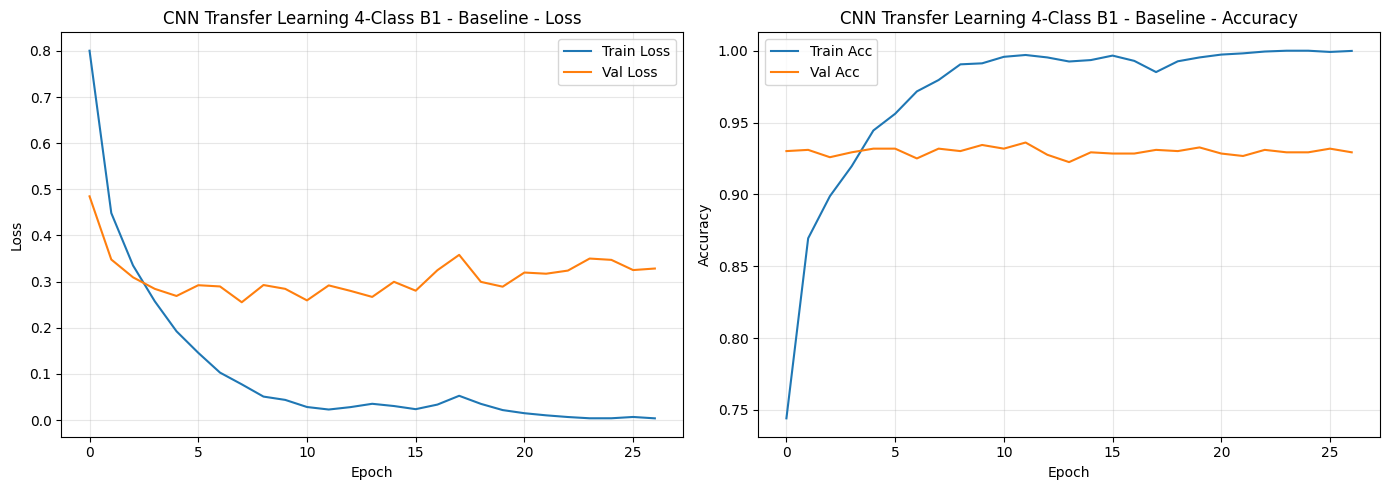

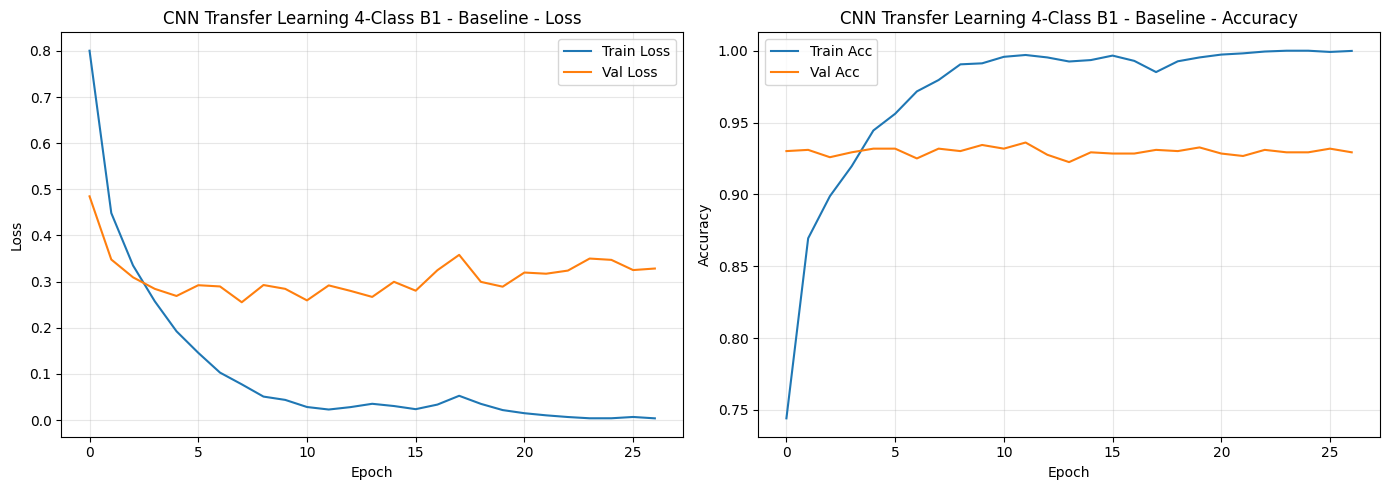

In [5]:
plot_training_history(history_b1, "CNN Transfer Learning 4-Class B1 - Baseline")

EVALUASI B1 - BASELINE


Test Loss: 0.1939
Test Accuracy: 0.9493
Test Macro F1: 0.3093
Test Weighted F1: 0.9399

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.99      0.98      1588
       happy       0.07      0.10      0.08        10
         sad       0.28      0.13      0.18        38
    negative       0.00      0.00      0.00        20

    accuracy                           0.95      1656
   macro avg       0.33      0.30      0.31      1656
weighted avg       0.93      0.95      0.94      1656



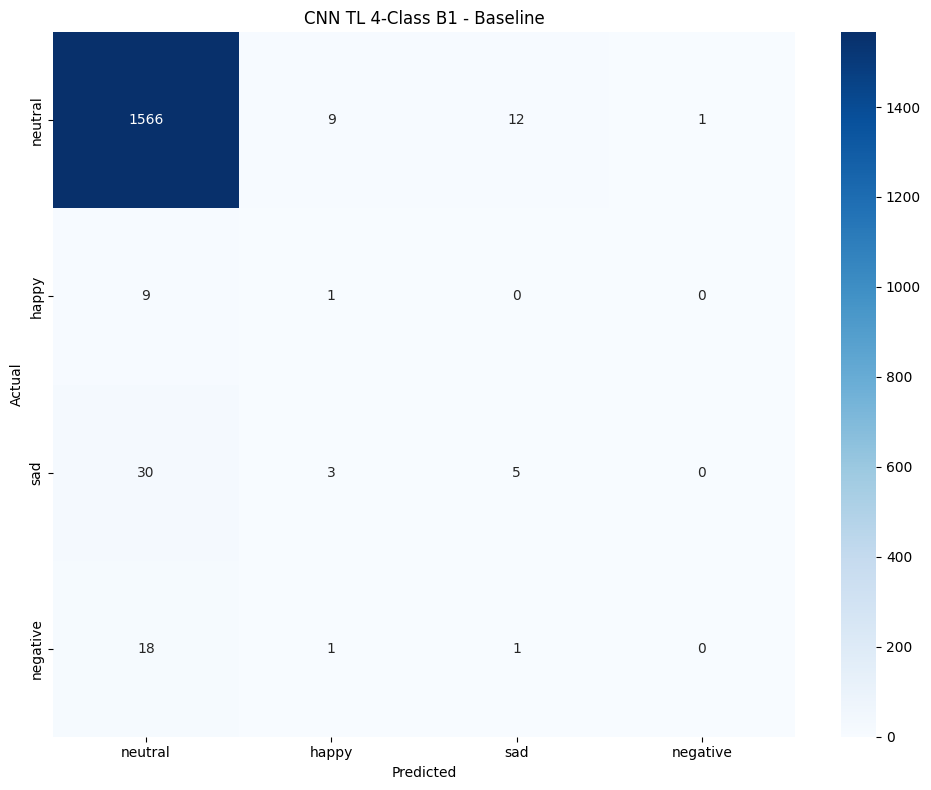

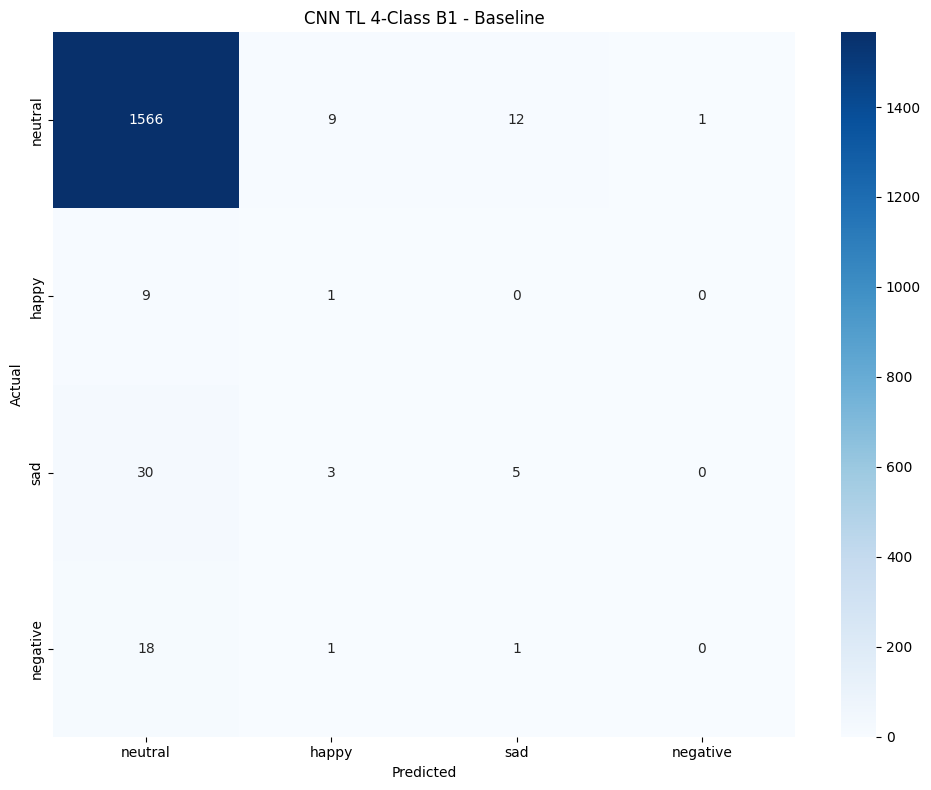

In [6]:
# Evaluate B1 on test set
print("=" * 60)
print("EVALUASI B1 - BASELINE")
print("=" * 60)
results_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "cnn", emotions=EMOTIONS)
plot_confusion_matrix(results_b1["confusion_matrix"], "CNN TL 4-Class B1 - Baseline", emotions=EMOTIONS)

## 4. Skenario B2: Dengan Class Weights

In [7]:
# B2: With class weights (Cui et al., 2019)
weights = get_class_weights(DATASET_DIR, device)
print(f"Class weights: {weights}")

model_b2 = EmotionCNNTransfer(num_classes=4, pretrained=True).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B2 (class weights)...")
history_b2, best_epoch_b2 = train_model(
    model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_tl_4c_b2_weighted.pth")
)

Class weights: tensor([1.0000, 1.8865, 2.5717, 7.3799], device='cuda:0')



Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.9918     0.6598     0.7914    0.8399   0.3057   0.000050  (23.9s)


     2      0.6532     0.8246     0.6580    0.8833   0.3812   0.000050  (23.8s)


     3      0.5016     0.8703     0.5041    0.9225   0.4655   0.000050  (23.9s)


...

    14      0.0184     0.9996     0.5751    0.9344   0.4183   0.000025  (23.8s)


    15      0.0189     0.9989     0.5658    0.9344   0.4129   0.000025  (23.8s)


    16      0.0150     0.9990     0.5746    0.9336   0.4205   0.000025  (23.9s)


    17      0.0127     0.9994     0.6172    0.9310   0.3800   0.000025  (23.8s)


    18      0.0110     0.9997     0.5779    0.9336   0.4074   0.000025  (23.8s)

Early stopping at epoch 18. Best epoch: 3 (val_f1=0.4655)

Best: epoch 3, val_acc=0.9225, val_f1=0.4655
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/cnn_transfer/cnn_tl_4c_b2_weighted.pth


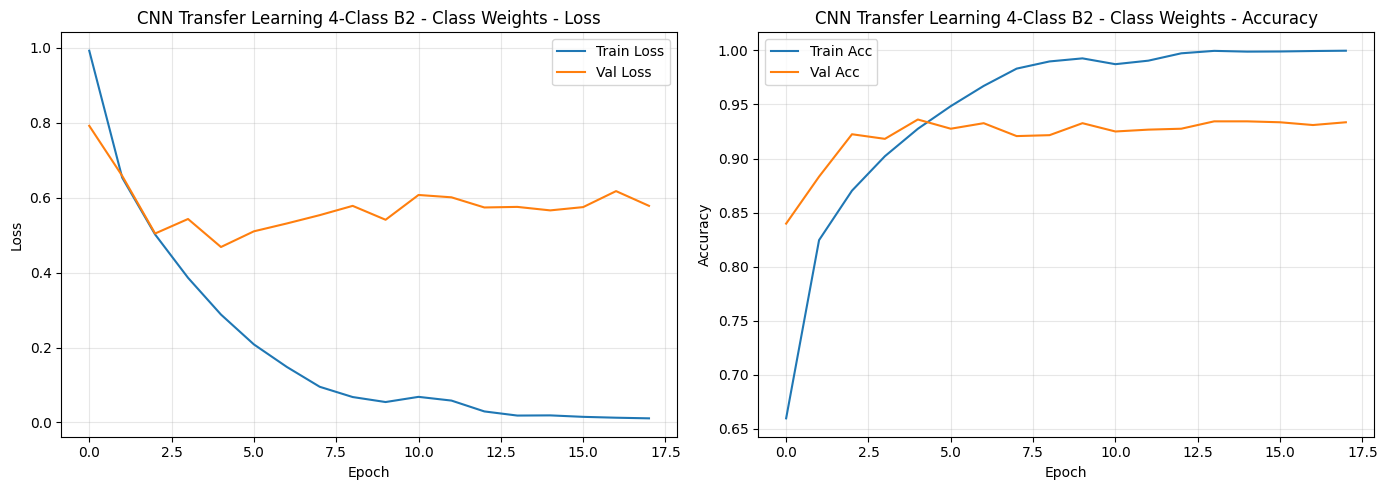

EVALUASI B2 - CLASS WEIGHTS


Test Loss: 0.5065
Test Accuracy: 0.9155
Test Macro F1: 0.4071
Test Weighted F1: 0.9322

Classification Report:
              precision    recall  f1-score   support

     neutral       0.98      0.94      0.96      1588
       happy       0.10      0.20      0.13        10
         sad       0.31      0.58      0.40        38
    negative       0.09      0.25      0.14        20

    accuracy                           0.92      1656
   macro avg       0.37      0.49      0.41      1656
weighted avg       0.95      0.92      0.93      1656



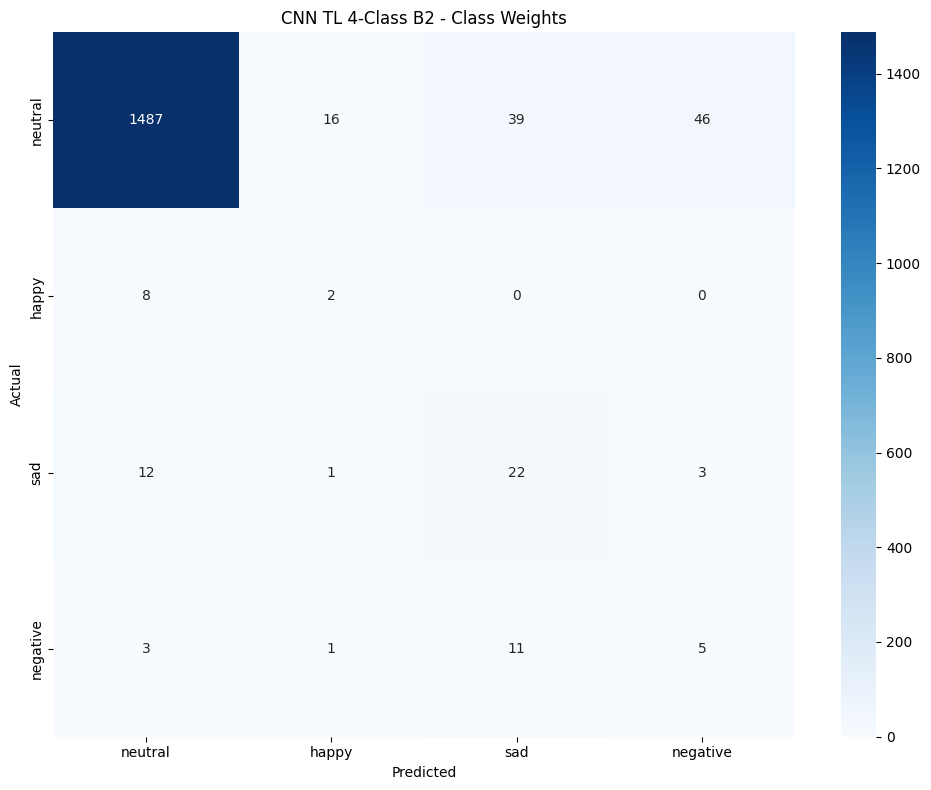

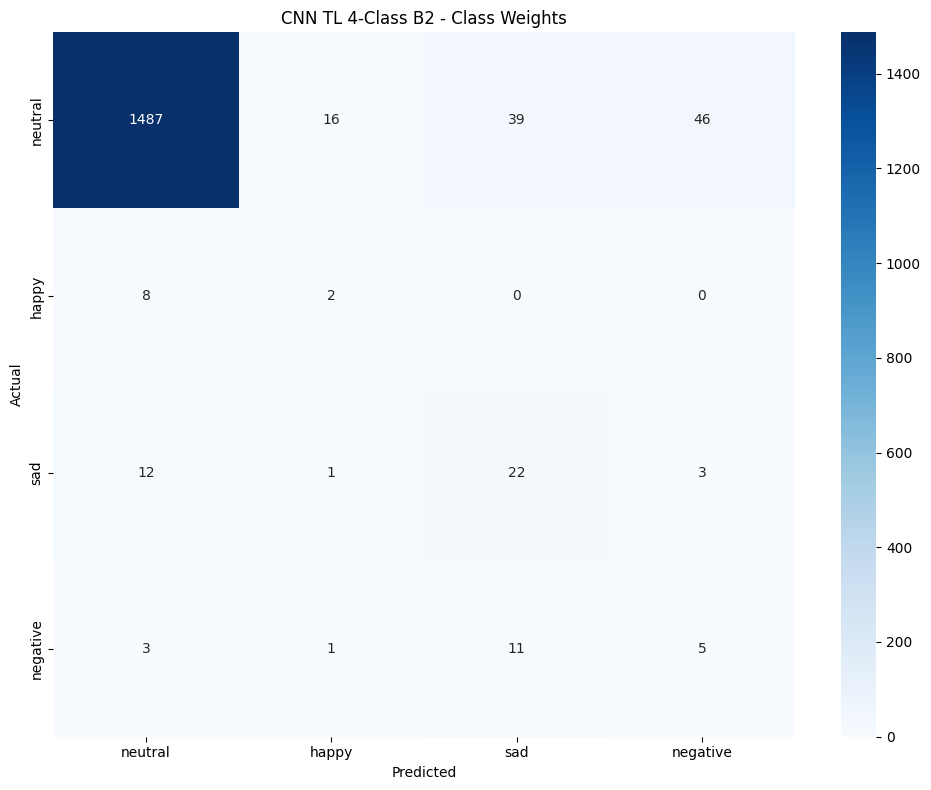

In [8]:
plot_training_history(history_b2, "CNN Transfer Learning 4-Class B2 - Class Weights")

print("=" * 60)
print("EVALUASI B2 - CLASS WEIGHTS")
print("=" * 60)
results_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "cnn", emotions=EMOTIONS)
plot_confusion_matrix(results_b2["confusion_matrix"], "CNN TL 4-Class B2 - Class Weights", emotions=EMOTIONS)

## 5. Skenario B3: Class Weights + Augmentasi

In [9]:
# B3: Class weights + augmented data
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
print(f"Augmented class weights: {weights_aug}")

model_b3 = EmotionCNNTransfer(num_classes=4, pretrained=True).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B3 (class weights + augmentation)...")
history_b3, best_epoch_b3 = train_model(
    model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_tl_4c_b3_augmented.pth")
)

Train: 7519 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
    negative: 600
Augmented class weights: tensor([1.0000, 1.8865, 2.5717, 2.2080], device='cuda:0')



Training B3 (class weights + augmentation)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.9251     0.6742     0.6726    0.9063   0.4136   0.000050  (26.4s)


     2      0.5436     0.8560     0.4825    0.9242   0.4720   0.000050  (26.8s)


     3      0.3839     0.8965     0.3669    0.9370   0.4442   0.000050  (26.7s)


...

    19      0.0114     0.9992     0.4718    0.9250   0.3803   0.000025  (26.4s)


    20      0.0070     1.0000     0.4874    0.9250   0.3695   0.000025  (26.6s)


    21      0.0058     1.0000     0.5114    0.9276   0.3804   0.000025  (26.5s)


    22      0.0048     1.0000     0.4849    0.9284   0.4091   0.000025  (26.4s)


    23      0.0046     0.9999     0.5057    0.9284   0.3780   0.000025  (26.5s)

Early stopping at epoch 23. Best epoch: 8 (val_f1=0.4863)

Best: epoch 8, val_acc=0.9361, val_f1=0.4863
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/cnn_transfer/cnn_tl_4c_b3_augmented.pth


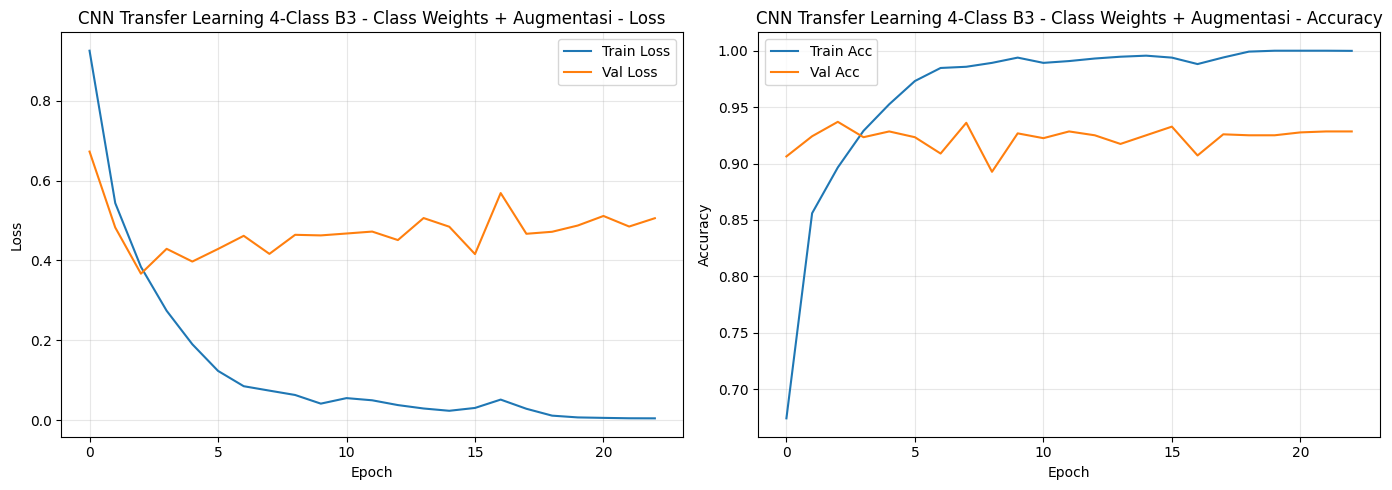

EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI


Test Loss: 0.3521
Test Accuracy: 0.9306
Test Macro F1: 0.2874
Test Weighted F1: 0.9313

Classification Report:
              precision    recall  f1-score   support

     neutral       0.97      0.97      0.97      1588
       happy       0.17      0.10      0.12        10
         sad       0.00      0.00      0.00        38
    negative       0.04      0.10      0.05        20

    accuracy                           0.93      1656
   macro avg       0.29      0.29      0.29      1656
weighted avg       0.93      0.93      0.93      1656



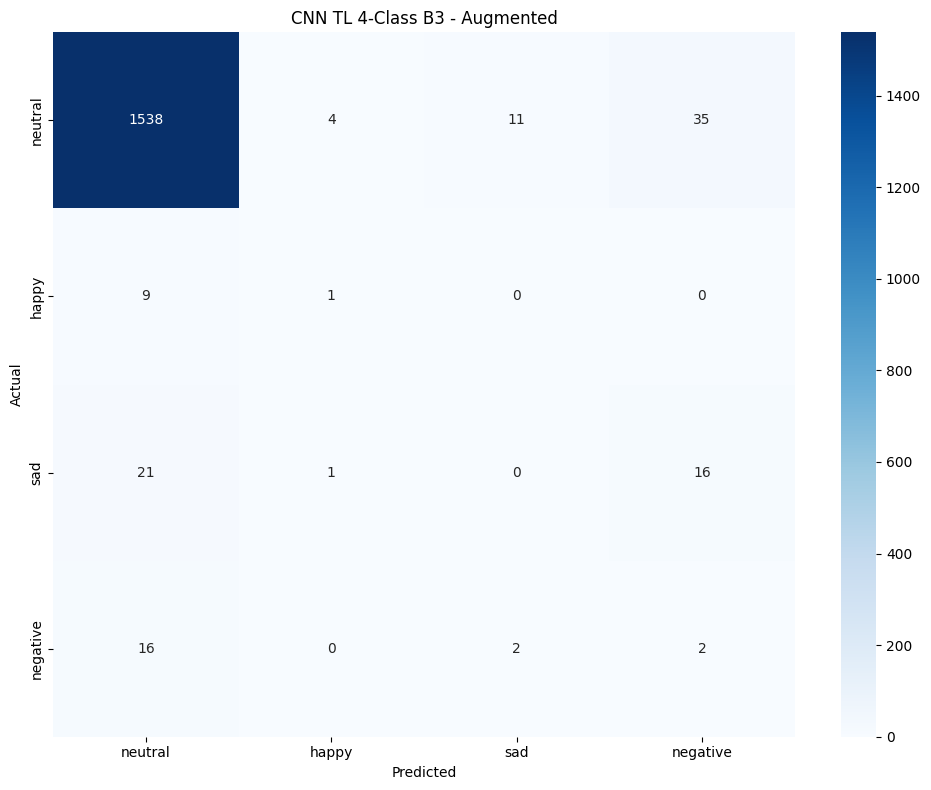

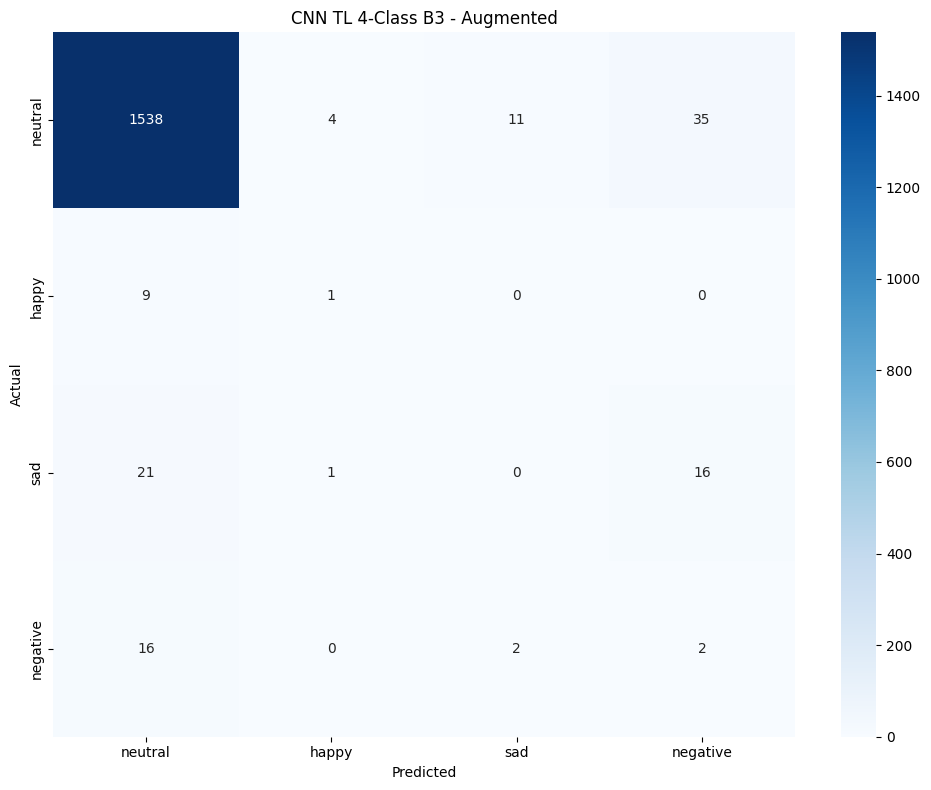

In [10]:
plot_training_history(history_b3, "CNN Transfer Learning 4-Class B3 - Class Weights + Augmentasi")

print("=" * 60)
print("EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI")
print("=" * 60)
results_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "cnn", emotions=EMOTIONS)
plot_confusion_matrix(results_b3["confusion_matrix"], "CNN TL 4-Class B3 - Augmented", emotions=EMOTIONS)

## 6. Perbandingan 3 Skenario

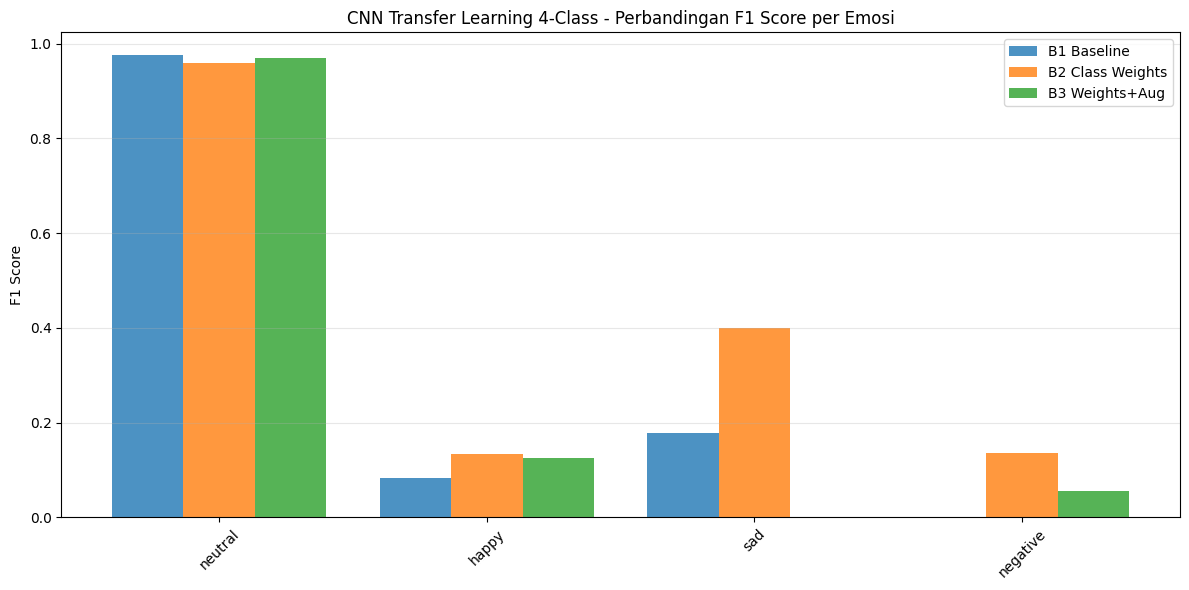

RINGKASAN CNN TRANSFER LEARNING 4-CLASS - 3 SKENARIO
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.9493     0.3093       0.9399
B2 Class Weights              0.9155     0.4071       0.9322
B3 Weights+Aug                0.9306     0.2874       0.9313


In [11]:
# Perbandingan per-class F1 score
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "CNN Transfer Learning 4-Class - Perbandingan F1 Score per Emosi", emotions=EMOTIONS)

# Summary table
print("=" * 70)
print("RINGKASAN CNN TRANSFER LEARNING 4-CLASS - 3 SKENARIO")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

## 7. Simpan Hasil

In [12]:
# Save results
cnn_tl_results = {}
for name, r in all_results.items():
    cnn_tl_results[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "cnn_transfer_4class_results.json", "w") as f:
    json.dump(cnn_tl_results, f, indent=2)
print(f"Results saved to {OUTPUT_DIR / 'cnn_transfer_4class_results.json'}")

Results saved to /home/bs000716/MOTHER-TANK/TRAIN/models/4class/cnn_transfer/cnn_transfer_4class_results.json
